In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as root_mse
from scipy.stats import pearsonr
from sklearn.metrics import r2_score as r2

In [3]:
result = pd.read_pickle('data/ccs_dataset.pkl.gz')
energies_df = pd.read_pickle('data/energies_df.pkl.gz')

In [4]:
ccs_inference = pd.read_pickle('gnn_inference/17-06-2025-models-ccs_inference_11159.pickle')
models_mapper = dict(zip(ccs_inference.columns[-13:-1],  
                    ['allegro_aflow_ccs-Pmm2+', 'allegro_random_ccs-Pmm2+', 
                     'nequip_aflow_ccs-Pmm2+', 'nequip_random_ccs-Pmm2+', 
                     'allegro_aflow_ccs', 'allegro_random_ccs', 
                     'nequip_aflow_ccs', 'nequip_random_ccs', 
                     'allegro_aflow_ccs-C2+', 'allegro_random_ccs-C2+', 
                     'nequip_aflow_ccs-C2+', 'nequip_random_ccs-C2+']))
ccs_inference.rename(mapper=models_mapper, axis=1, inplace=True)
ccs_available_models = ccs_inference.columns[:-1]
for model in ccs_available_models:
    ccs_inference[model] /= ccs_inference['length']
print('the inference read includes following models:\n', '\n '.join(ccs_available_models))
ccs_inference['compound'] = [f'{i}.vasp' for i in ccs_inference.index]
ccs_inference.set_index('compound', inplace=True)
print(ccs_inference)
print(result.set_index('compound').iloc[:,:2])
print(energies_df.loc[ccs_inference.index])
ccs_inference = pd.concat((ccs_inference, result.set_index('compound'), 
                           energies_df.loc[ccs_inference.index]), axis=1)
assert all(ccs_inference['natoms'] == ccs_inference['length'])
ccs_inference.drop('length', axis=1, inplace=True)
ccs_inference.shape
print(ccs_inference)

the inference read includes following models:
 allegro_aflow_2dmd-ldc
 allegro_random_2dmd-ldc
 nequip_aflow_2dmd-ldc
 nequip_random_2dmd-ldc
 allegro_aflow_2dmd-hdc
 allegro_random_2dmd-hdc
 nequip_aflow_2dmd-hdc
 nequip_random_2dmd-hdc
 allegro_aflow_2dmd
 allegro_random_2dmd
 nequip_aflow_2dmd
 nequip_random_2dmd
 allegro_aflow_ccs-Pmm2+
 allegro_random_ccs-Pmm2+
 nequip_aflow_ccs-Pmm2+
 nequip_random_ccs-Pmm2+
 allegro_aflow_ccs
 allegro_random_ccs
 nequip_aflow_ccs
 nequip_random_ccs
 allegro_aflow_ccs-C2+
 allegro_random_ccs-C2+
 nequip_aflow_ccs-C2+
 nequip_random_ccs-C2+
            allegro_aflow_2dmd-ldc  allegro_random_2dmd-ldc  \
compound                                                      
0.vasp                   -0.550030                -0.549916   
1.vasp                   -0.351932                -0.352496   
2.vasp                   -0.121152                -0.132716   
3.vasp                   -0.131063                -0.087269   
4.vasp                   -0.208197  

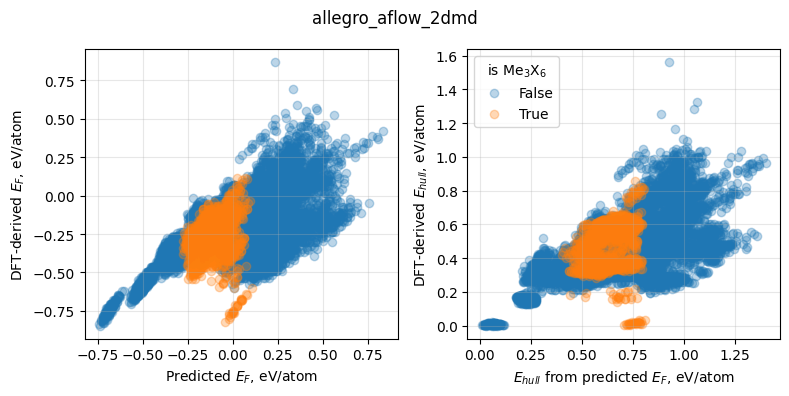

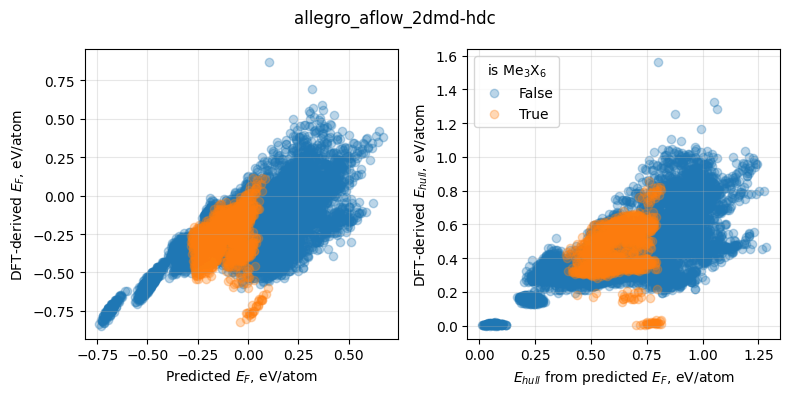

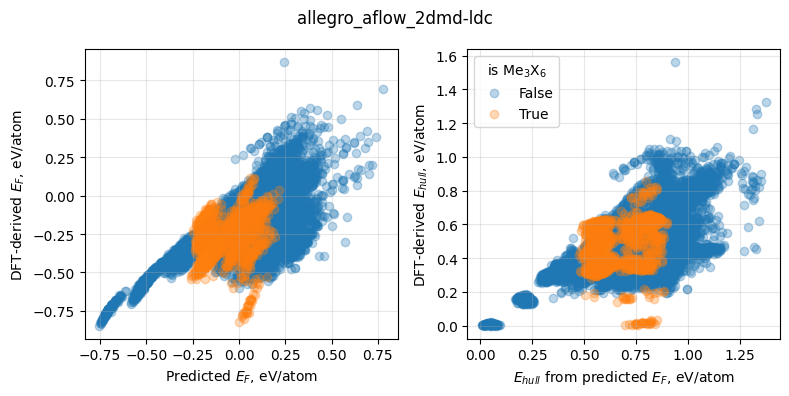

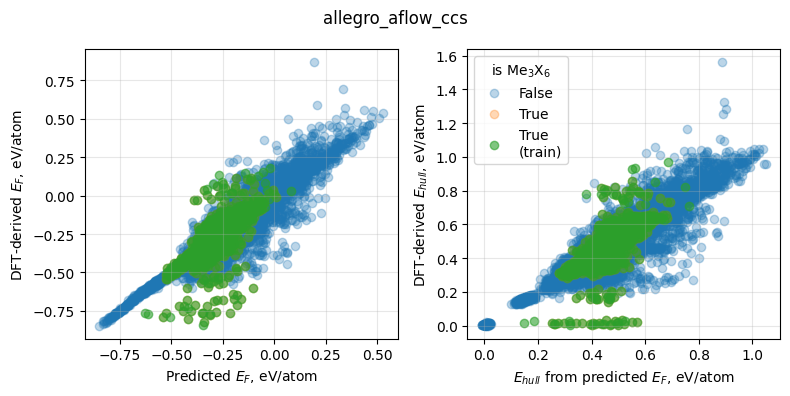

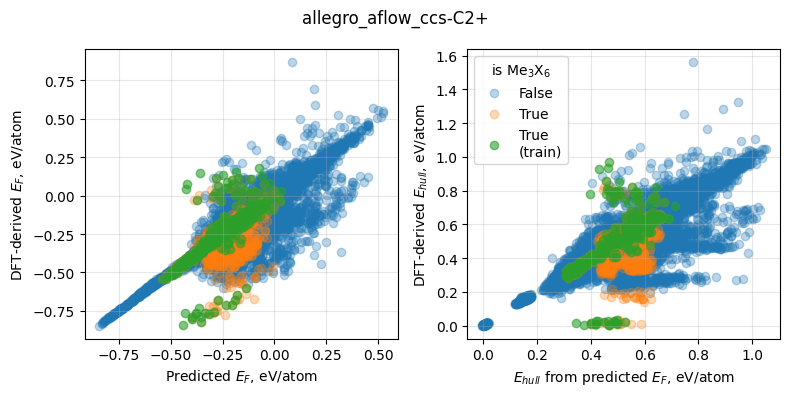

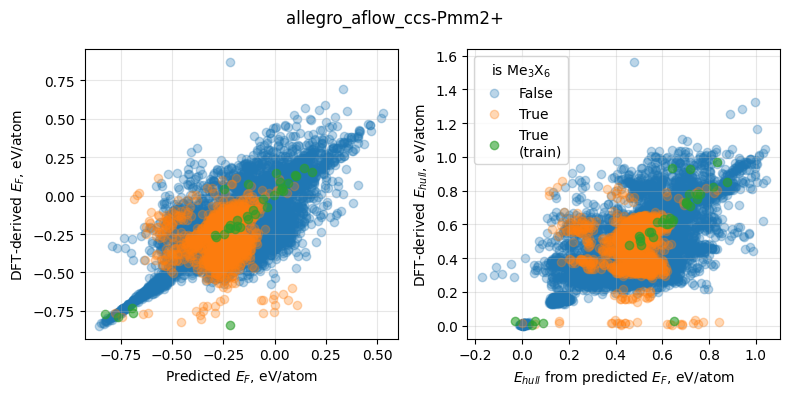

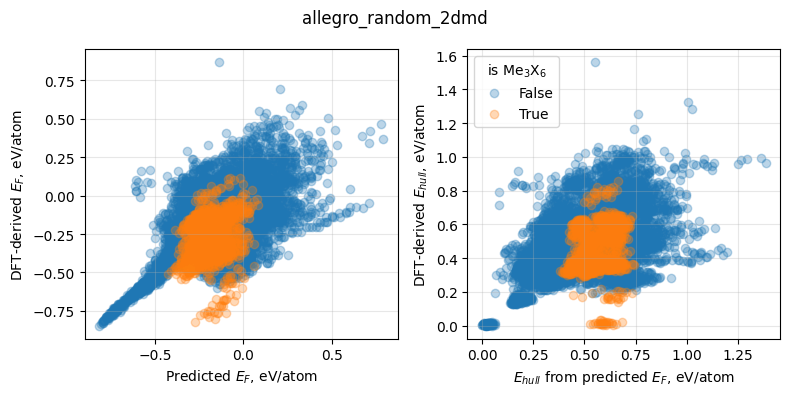

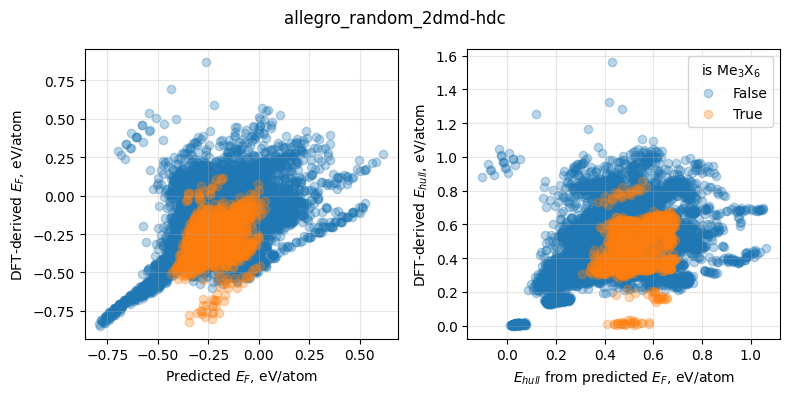

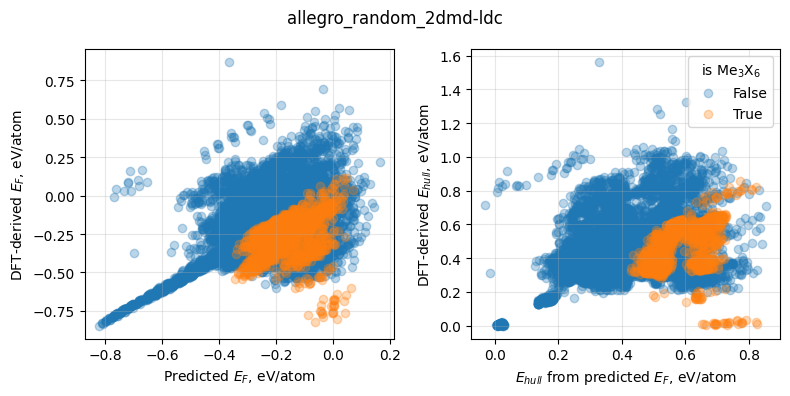

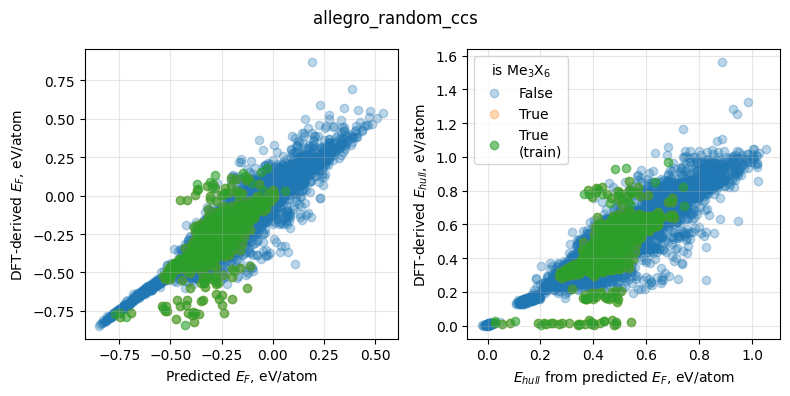

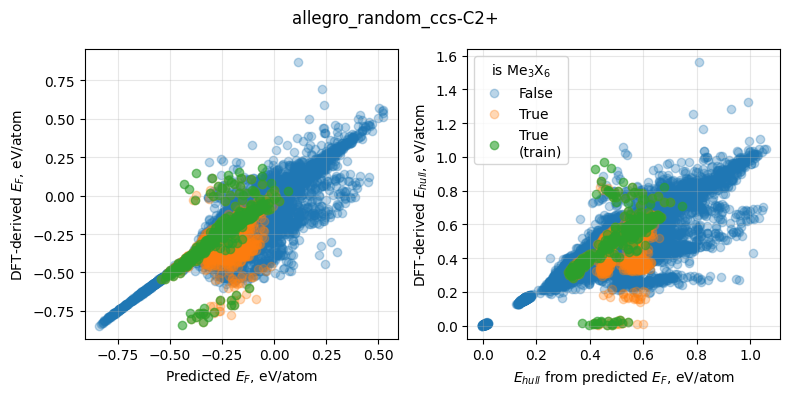

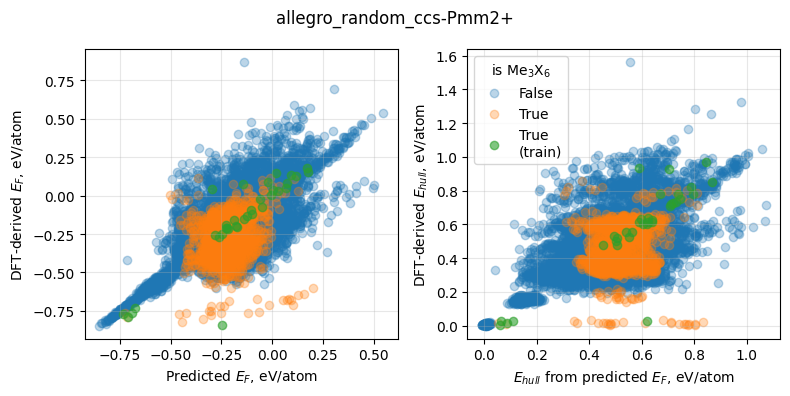

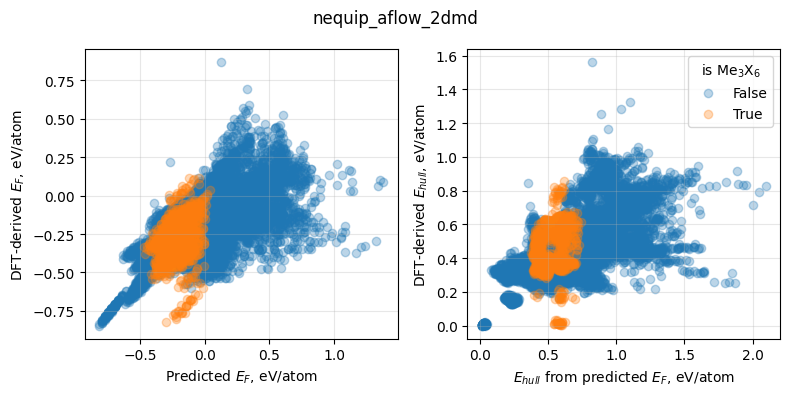

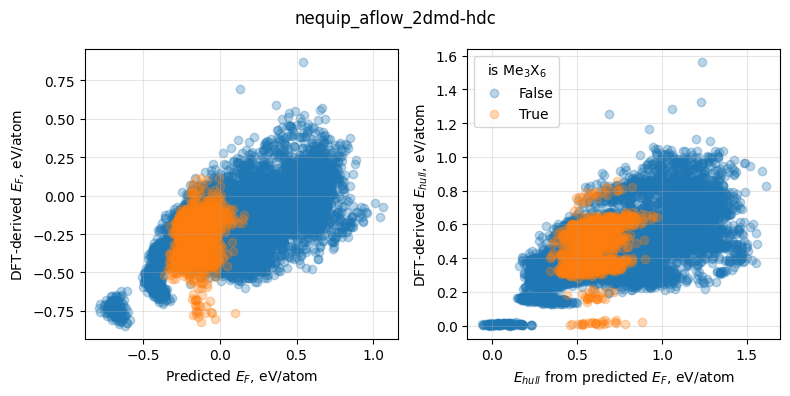

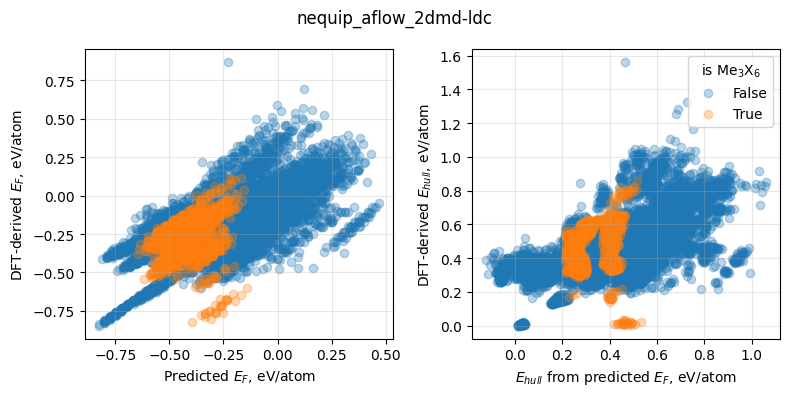

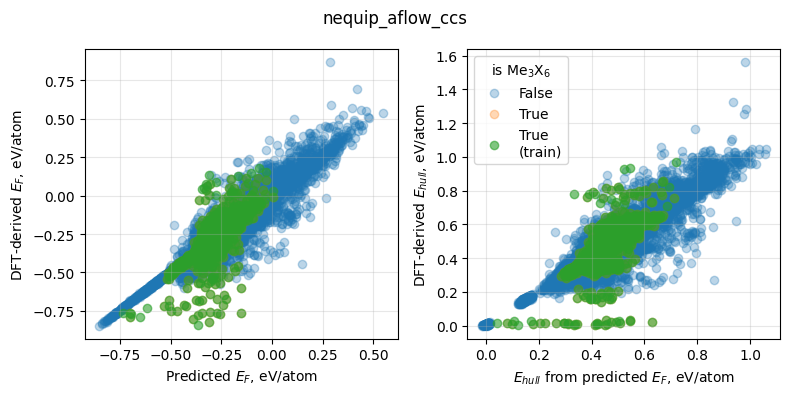

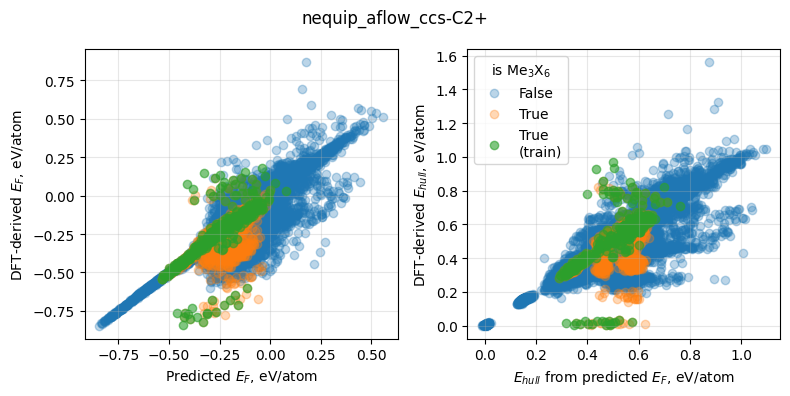

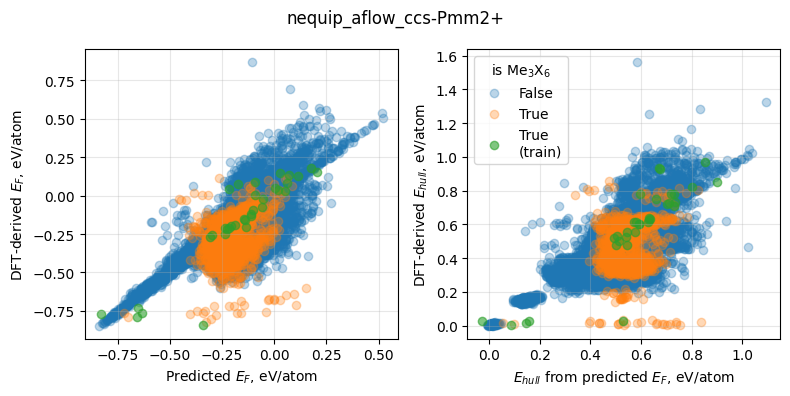

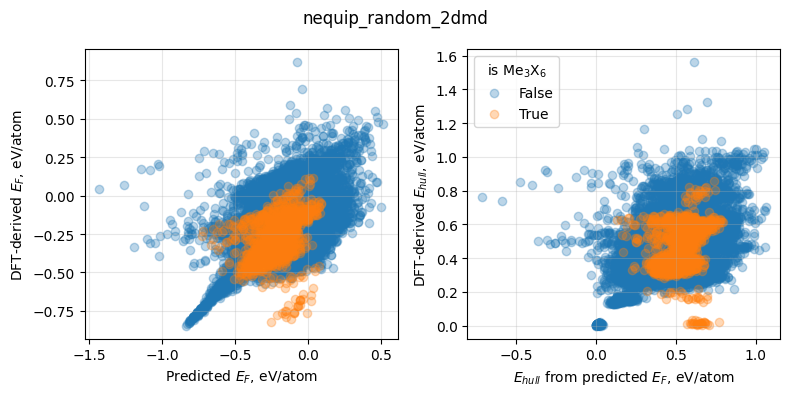

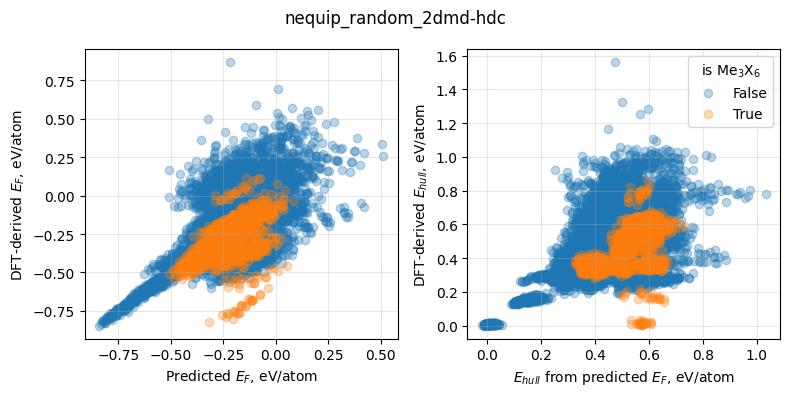

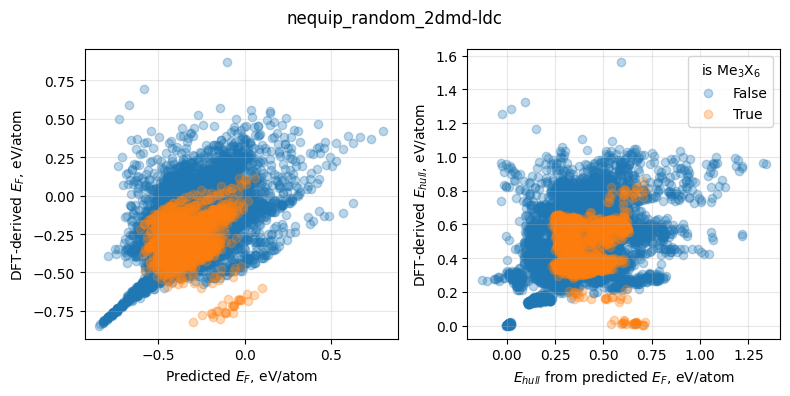

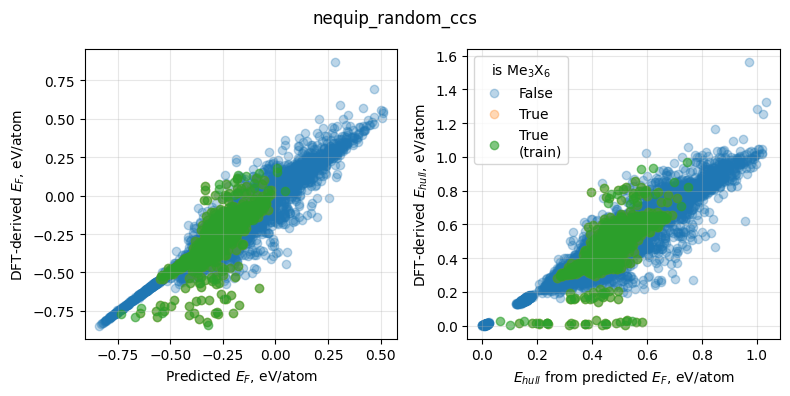

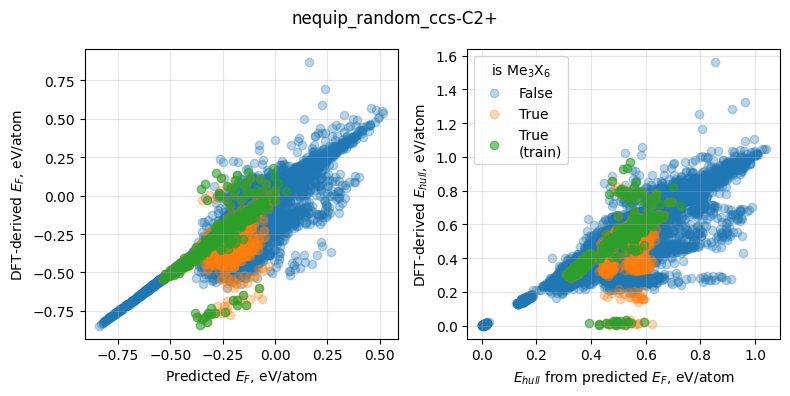

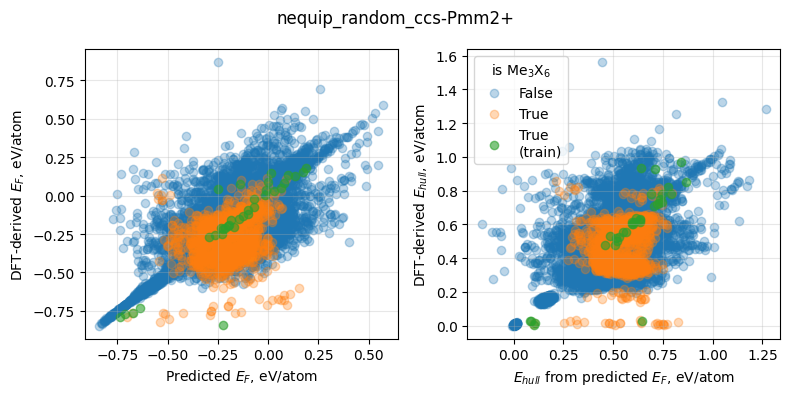

In [5]:
test = ccs_inference[ccs_inference['Space_group_no'] <= 8]
for model in sorted(ccs_available_models):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
    for is_Me3X6 in [False, True]:
        sub_test = test[test['Me3X6_exactly'] == is_Me3X6]
        axs[0].scatter(sub_test[model], sub_test['formation_energy_per_atom'], alpha=0.3, label=is_Me3X6)
        axs[1].scatter(sub_test[model] - sub_test['Reference_hull_E'], sub_test['E_above_hull'], alpha=0.3, label=is_Me3X6)
    if re.match('^.*2dmd.*$', model) == None:
        if model.endswith('ccs-Pmm2+'):
            space_group_limit = 8
        elif model.endswith('ccs-C2+'):
            space_group_limit = 1
        else:
            space_group_limit = 0
        sub_test = ccs_inference[(ccs_inference['Me3X6_exactly'] == is_Me3X6) & (ccs_inference['Space_group_no'] > space_group_limit)]
        axs[0].scatter(sub_test[model], sub_test['formation_energy_per_atom'], alpha=0.6, label='True\n(train)')
        axs[1].scatter(sub_test[model] - sub_test['Reference_hull_E'], sub_test['E_above_hull'], alpha=0.6, label='True\n(train)')
    plt.suptitle(model)
    axs[0].set_xlabel('Predicted $E_F$, eV/atom')
    axs[0].set_ylabel('DFT-derived $E_F$, eV/atom')
    axs[1].set_xlabel('$E_{hull}$ from predicted $E_F$, eV/atom')
    axs[1].set_ylabel('DFT-derived $E_{hull}$, eV/atom')
    axs[1].legend(title='is Me$_{3}$X$_{6}$')
    for i in range(2):
        axs[i].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
def getRMSEforModelEhullLimit (test_set, model, limit):
    subset = test_set[test_set['E_above_hull'] < limit]
    try:
        rmse = root_mse(subset['formation_energy_pa'], subset[model])
    except:
        rmse = np.nan
    return rmse

['2dmd-ldc', '2dmd-hdc', '2dmd', 'ccs-Pmm2+']
test shape: (9291, 63)


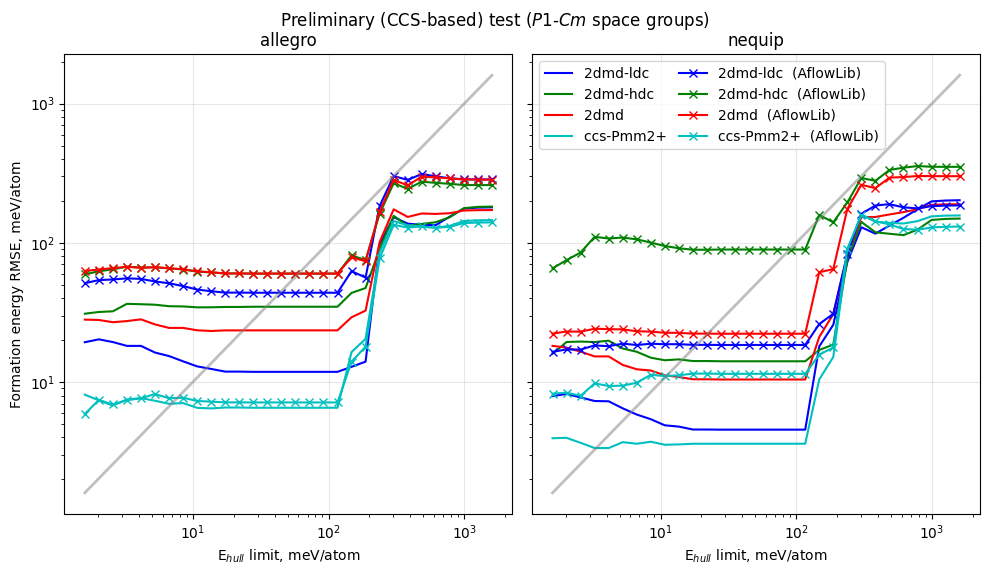

['2dmd-ldc', '2dmd-hdc', '2dmd', 'ccs-Pmm2+', 'ccs-C2+']
test shape: (6156, 63)


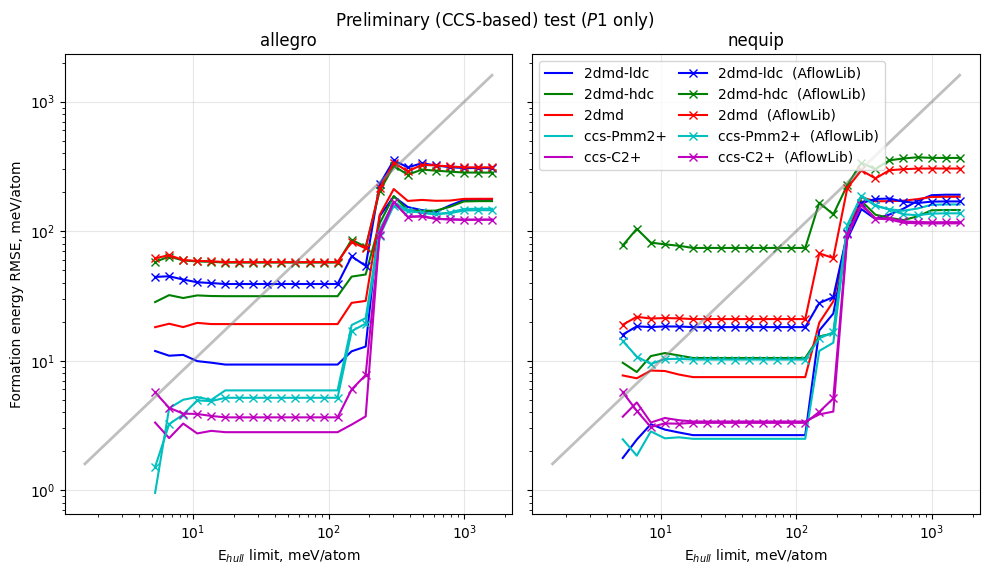

In [7]:
limits = 1.6e-3 * np.logspace(0, 3, 30)
modes_all = ['2dmd-ldc', '2dmd-hdc', '2dmd', 'ccs-Pmm2+', 'ccs-C2+', 'ccs']
mode_color = dict(zip(modes_all, ['b', 'g', 'r', 'c', 'm', 'grey']))

for test_set_sg_limit in [8, 1]:
    test_set_tag = 'Preliminary (CCS-based) test ' + ('($P1$-$Cm$ space groups)' if test_set_sg_limit == 8 else '($P1$ only)')
    modes = modes_all[:(-2 if test_set_sg_limit == 8 else -1)]
    test_no_Me3X6 = ccs_inference[(ccs_inference['Space_group_no'] <= test_set_sg_limit) & (~ccs_inference['Me3X6_exactly'])]
    print('test shape:', test_no_Me3X6.shape)
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True)
    fig.suptitle(test_set_tag, y=0.95)
    for arch_id, architect in enumerate(['allegro', 'nequip']):
        for pretrain in ['random', 'aflow']:
            pretrain_style = '-' if pretrain == 'random' else 'x-'
            for mode in modes:
                model = f'{architect}_{pretrain}_{mode}'
                pretrain_tag = ' (AflowLib)' if pretrain == 'aflow' else ''
                thick_line = False
                lw = 2 if thick_line  else 1.5
                axs[arch_id].plot(1e3 * limits, 1e3 * np.array([getRMSEforModelEhullLimit(test_no_Me3X6, model, limit) for limit in limits]), 
                                  pretrain_style, color=mode_color[mode], 
                                  label=f'{mode} {pretrain_tag}', lw=lw)
        axs[arch_id].plot(1e3 * limits, 1e3 * limits, color='grey', lw=2, alpha=0.5)
        axs[arch_id].set_xlabel('E$_{hull}$ limit, meV/atom')
        axs[0].set_ylabel('Formation energy RMSE, meV/atom')
        axs[arch_id].set_title(architect)
        axs[arch_id].grid(alpha=0.3)
        axs[arch_id].set_xscale('log')
        axs[arch_id].set_yscale('log')
    axs[arch_id].legend(ncol=2, columnspacing=0.6)
    plt.tight_layout()
    plt.show()

In [8]:
score_list = []
models_available = [col for col in test_no_Me3X6.columns if (col.startswith('allegro') or col.startswith('nequip'))]

for model_id in range(len(ccs_available_models)):
    model = ccs_available_models[model_id]
    rmse = root_mse(test_no_Me3X6['formation_energy_pa'], test_no_Me3X6[model])
    r_val = pearsonr(test_no_Me3X6['formation_energy_pa'], test_no_Me3X6[model])[0]
    r2_val = r2(test_no_Me3X6['formation_energy_pa'], test_no_Me3X6[model])
   
    mask = test_no_Me3X6['natoms'] > 9    
    rmse_ = root_mse(test_no_Me3X6[mask]['formation_energy_pa'], test_no_Me3X6[mask][model])
    r_val_ = pearsonr(test_no_Me3X6[mask]['formation_energy_pa'], test_no_Me3X6[mask][model])[0]
    r2_val_ = r2(test_no_Me3X6[mask]['formation_energy_pa'], test_no_Me3X6[mask][model])    
    score_list += [[rmse, r_val, r2_val, rmse_, r_val_, r2_val_]]

scores = pd.DataFrame(score_list, index=ccs_available_models, 
                      columns=['rmse, eV/atom', 'Pearson R', 'R2', 
                               'rmse (10+ at.), eV/atom', 'Pearson R (10+ at.)', 'R2 (10+ at.)'])
scores.sort_values('rmse (10+ at.), eV/atom', inplace=True)
scores

,"rmse, eV/atom",Pearson R,R2,"rmse (10+ at.), eV/atom",Pearson R (10+ at.),R2 (10+ at.)
nequip_aflow_ccs,0.065495,0.930464,0.865691,0.027139,0.978043,0.955922
nequip_random_ccs,0.061603,0.939079,0.881178,0.027603,0.977108,0.954402
allegro_random_ccs,0.066987,0.927219,0.859502,0.028363,0.975769,0.951854
allegro_aflow_ccs,0.069887,0.920764,0.847075,0.030162,0.973668,0.945553
allegro_aflow_ccs-C2+,0.122744,0.799012,0.528270,0.036308,0.963476,0.921104
nequip_random_ccs-C2+,0.114922,0.817207,0.586479,0.036439,0.963442,0.920536
allegro_random_ccs-C2+,0.122724,0.802168,0.528429,0.037668,0.962198,0.915082
nequip_aflow_ccs-C2+,0.117425,0.811443,0.568269,0.038311,0.958827,0.912159
nequip_random_2dmd-hdc,0.145725,0.607187,0.335098,0.051533,0.925614,0.841068
nequip_random_2dmd,0.184237,0.516224,-0.062786,0.057505,0.899789,0.802093
